In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
pd.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# eda / data cleaning

## data structure

In [18]:
df = pd.read_csv("/content/drive/MyDrive/ADL_Group14/rotation_schedule_data_2023-25deid.csv")

print("shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("columns")
print(df.columns.tolist(), "\n")

print("data types")
print(df.dtypes, "\n")

df.head()

shape
Rows: 7552, Columns: 20

columns
['Rotation ID', 'Schools', 'Sites', 'Program', 'Experience', 'Student Count', 'Student Slots', 'Students', 'Start Date', 'End Date', 'Shift Start', 'Shift End', 'Total Hours per Person', 'Days of the Week', 'Faculty Name', 'Preceptor Name', 'Rotation Type', 'Course', 'Unit', 'Status'] 

data types
Rotation ID               float64
Schools                    object
Sites                      object
Program                    object
Experience                 object
Student Count             float64
Student Slots             float64
Students                   object
Start Date                 object
End Date                   object
Shift Start                object
Shift End                  object
Total Hours per Person    float64
Days of the Week           object
Faculty Name               object
Preceptor Name             object
Rotation Type              object
Course                     object
Unit                       object
Status          

,Rotation ID,Schools,Sites,Program,Experience,Student Count,Student Slots,Students,Start Date,End Date,Shift Start,Shift End,Total Hours per Person,Days of the Week,Faculty Name,Preceptor Name,Rotation Type,Course,Unit,Status
0,312937.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,8.0,8.0,"10000, 10001, 10002, 10003, 10004, 10005, 1000...",1/9/2023,4/24/2023,7:00,19:00,144.0,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed)
1,312939.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0.0,8.0,No Students,5/8/2023,6/26/2023,7:00,19:00,96.0,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
2,312940.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0.0,8.0,No Students,5/12/2023,6/30/2023,7:00,19:00,96.0,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
3,312944.0,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0.0,6.0,No Students,1/9/2023,4/24/2023,7:00,19:00,144.0,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
4,312945.0,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0.0,6.0,No Students,1/13/2023,4/28/2023,7:00,19:00,144.0,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)


In [19]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df

,rotation_id,schools,sites,program,experience,student_count,student_slots,students,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status
0,312937.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,8.0,8.0,"10000, 10001, 10002, 10003, 10004, 10005, 1000...",1/9/2023,4/24/2023,7:00,19:00,144.0,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed)
1,312939.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0.0,8.0,No Students,5/8/2023,6/26/2023,7:00,19:00,96.0,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
2,312940.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0.0,8.0,No Students,5/12/2023,6/30/2023,7:00,19:00,96.0,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
3,312944.0,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0.0,6.0,No Students,1/9/2023,4/24/2023,7:00,19:00,144.0,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
4,312945.0,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0.0,6.0,No Students,1/13/2023,4/28/2023,7:00,19:00,144.0,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Preceptor,NaN,NaN,NaN,NaN
7548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Preceptor,NaN,NaN,NaN,NaN
7549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Preceptor,NaN,NaN,NaN,NaN
7550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Preceptor,NaN,NaN,NaN,NaN


## missing values

In [20]:
# Count null values
null_count = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Count "ID Missing" values in text columns
id_missing_count = pd.Series(0, index=df.columns)
for col in df.select_dtypes(include='object').columns:
    id_missing_count[col] = df[col].astype(str).str.contains('ID Missing', na=False).sum()

# Total missing = null + ID Missing
total_missing = null_count + id_missing_count
total_pct = (total_missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Null': null_count,
    'ID Missing': id_missing_count,
    'Total Missing': total_missing,
    'Percent': total_pct
})

print(missing_df[missing_df['Total Missing'] > 0])

                        Null  ID Missing  Total Missing  Percent
rotation_id             3769           0           3769    49.91
schools                 3769           0           3769    49.91
sites                   3769           0           3769    49.91
program                 3769           0           3769    49.91
experience              3769           0           3769    49.91
student_count           3769           0           3769    49.91
student_slots           3769           0           3769    49.91
students                3769           0           3769    49.91
start_date              3769           0           3769    49.91
end_date                3769           0           3769    49.91
shift_start             3769           0           3769    49.91
shift_end               3769           0           3769    49.91
total_hours_per_person  3769           0           3769    49.91
days_of_the_week        4034           0           4034    53.42
faculty_name            4

In [21]:
# df[df['rotation_id'].isna()] na rotation ids are just empty rows so we can drop them
rot_sched = df.dropna(subset=['rotation_id'])
rot_sched

,rotation_id,schools,sites,program,experience,student_count,student_slots,students,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status
0,312937.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,8.0,8.0,"10000, 10001, 10002, 10003, 10004, 10005, 1000...",1/9/2023,4/24/2023,7:00,19:00,144.0,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed)
1,312939.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0.0,8.0,No Students,5/8/2023,6/26/2023,7:00,19:00,96.0,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
2,312940.0,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0.0,8.0,No Students,5/12/2023,6/30/2023,7:00,19:00,96.0,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
3,312944.0,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0.0,6.0,No Students,1/9/2023,4/24/2023,7:00,19:00,144.0,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
4,312945.0,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0.0,6.0,No Students,1/13/2023,4/28/2023,7:00,19:00,144.0,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,625920.0,Emory University - SON Pre-licensure,Emory Decatur Hospital,Nursing,Precepted Rotation,1.0,1.0,13692,11/10/2025,11/11/2025,0:00:01,23:59:00,8.0,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Stepdown Unit - 2600,Completed
3779,625921.0,Emory University - SON Pre-licensure,Emory Hillandale Hospital,Nursing,Precepted Rotation,1.0,1.0,13693,11/10/2025,11/11/2025,0:00:01,23:59:00,8.0,NaN,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Emergency Dept,Completed
3780,625923.0,Emory University - SON Pre-licensure,Emory Long Term Acute Care Hospital,Nursing,Precepted Rotation,1.0,1.0,13694,11/10/2025,11/11/2025,0:00:01,23:59:00,8.0,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,LTAC,Completed
3781,626888.0,South College - Atlanta Campus - Nursing,Emory Saint Joseph's Hospital,Nursing,Precepted Rotation,0.0,1.0,No Students,10/27/2025,12/18/2025,0:00:01,23:59:00,90.0,"Tue, Wed, Thu, Fri, Sat, Sun",No Faculty,No Preceptor,Emergency,NSG 2650 - Adult Health Practicum,ED,Denied


In [22]:
rot_sched[['student_count', 'student_slots', 'total_hours_per_person']].describe()

,student_count,student_slots,total_hours_per_person
count,3783.000000,3783.000000,3783.000000
mean,2.133492,3.950568,72.017446
std,2.696904,4.111603,43.554730
min,0.000000,1.000000,1.000000
25%,0.000000,1.000000,24.000000
50%,1.000000,1.000000,60.000000
75%,4.000000,6.000000,120.000000
max,32.000000,132.000000,212.000000


In [23]:
#fix formats
rot_sched['rotation_id'] = rot_sched['rotation_id'].astype('Int64').astype(str)
rot_sched['schools'] = rot_sched['schools'].astype(str)
rot_sched['sites'] = rot_sched['sites'].astype(str)
rot_sched['experience'] = rot_sched['experience'].astype(str)
rot_sched['rotation_type'] = rot_sched['rotation_type'].astype(str)
rot_sched['course'] = rot_sched['course'].astype(str)
rot_sched['unit'] = rot_sched['unit'].astype(str)
rot_sched['status'] = rot_sched['status'].astype(str)

#what to do with Faculty Name, Preceptor Name?

rot_sched['student_count'] = rot_sched['student_count'].astype(int)
rot_sched['student_slots'] = rot_sched['student_slots'].astype(int)
rot_sched['total_hours_per_person'] = rot_sched['total_hours_per_person'].astype(int)

rot_sched['start_date'] = pd.to_datetime(rot_sched['start_date'])
rot_sched['end_date'] = pd.to_datetime(rot_sched['end_date'])


rot_sched

/tmp/ipython-input-403095835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rot_sched['rotation_id'] = rot_sched['rotation_id'].astype('Int64').astype(str)
/tmp/ipython-input-403095835.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rot_sched['schools'] = rot_sched['schools'].astype(str)
/tmp/ipython-input-403095835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

,rotation_id,schools,sites,program,experience,student_count,student_slots,students,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,8,8,"10000, 10001, 10002, 10003, 10004, 10005, 1000...",2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed)
1,312939,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0,8,No Students,2023-05-08,2023-06-26,7:00,19:00,96,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
2,312940,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Nursing,Cohort Rotation,0,8,No Students,2023-05-12,2023-06-30,7:00,19:00,96,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
3,312944,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0,6,No Students,2023-01-09,2023-04-24,7:00,19:00,144,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
4,312945,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Nursing,Cohort Rotation,0,6,No Students,2023-01-13,2023-04-28,7:00,19:00,144,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,625920,Emory University - SON Pre-licensure,Emory Decatur Hospital,Nursing,Precepted Rotation,1,1,13692,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Stepdown Unit - 2600,Completed
3779,625921,Emory University - SON Pre-licensure,Emory Hillandale Hospital,Nursing,Precepted Rotation,1,1,13693,2025-11-10,2025-11-11,0:00:01,23:59:00,8,NaN,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Emergency Dept,Completed
3780,625923,Emory University - SON Pre-licensure,Emory Long Term Acute Care Hospital,Nursing,Precepted Rotation,1,1,13694,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,LTAC,Completed
3781,626888,South College - Atlanta Campus - Nursing,Emory Saint Joseph's Hospital,Nursing,Precepted Rotation,0,1,No Students,2025-10-27,2025-12-18,0:00:01,23:59:00,90,"Tue, Wed, Thu, Fri, Sat, Sun",No Faculty,No Preceptor,Emergency,NSG 2650 - Adult Health Practicum,ED,Denied


In [24]:
#check rotation id uniqueness
rot_sched['rotation_id'].duplicated().sum()

np.int64(0)

In [25]:
# print(rot_sched['program'].unique()) #just 'Nursing'
# rot_sched[rot_sched['program'].isna()] #none

#can drop col
rot_sched = rot_sched.drop('program', axis=1)
rot_sched

,rotation_id,schools,sites,experience,student_count,student_slots,students,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,"10000, 10001, 10002, 10003, 10004, 10005, 1000...",2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed)
1,312939,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,0,8,No Students,2023-05-08,2023-06-26,7:00,19:00,96,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
2,312940,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,0,8,No Students,2023-05-12,2023-06-30,7:00,19:00,96,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied)
3,312944,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Cohort Rotation,0,6,No Students,2023-01-09,2023-04-24,7:00,19:00,144,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
4,312945,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Cohort Rotation,0,6,No Students,2023-01-13,2023-04-28,7:00,19:00,144,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,625920,Emory University - SON Pre-licensure,Emory Decatur Hospital,Precepted Rotation,1,1,13692,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Stepdown Unit - 2600,Completed
3779,625921,Emory University - SON Pre-licensure,Emory Hillandale Hospital,Precepted Rotation,1,1,13693,2025-11-10,2025-11-11,0:00:01,23:59:00,8,NaN,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Emergency Dept,Completed
3780,625923,Emory University - SON Pre-licensure,Emory Long Term Acute Care Hospital,Precepted Rotation,1,1,13694,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,LTAC,Completed
3781,626888,South College - Atlanta Campus - Nursing,Emory Saint Joseph's Hospital,Precepted Rotation,0,1,No Students,2025-10-27,2025-12-18,0:00:01,23:59:00,90,"Tue, Wed, Thu, Fri, Sat, Sun",No Faculty,No Preceptor,Emergency,NSG 2650 - Adult Health Practicum,ED,Denied


In [26]:
print(rot_sched['status'].unique())

['Archived (Completed)' 'Archived (Denied)' 'Archived (Withdrawn)'
 'Denied' 'Completed' 'Withdrawn']


In [27]:
print(rot_sched['preceptor_name'].isna().sum())

707


In [28]:
#standardize status
rot_sched['status_clean'] = rot_sched['status'].replace({
    'Archived (Completed)': 'Completed',
    'Completed': 'Completed',
    'Archived (Denied)': 'Denied',
    'Denied': 'Denied',
    'Archived (Withdrawn)': 'Withdrawn',
    'Withdrawn': 'Withdrawn'
})

status_map = {'Completed': 1, 'Denied': 2, 'Withdrawn': 3}
rot_sched['status_clean'] = rot_sched['status_clean'].map(status_map)
rot_sched

,rotation_id,schools,sites,experience,student_count,student_slots,students,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status,status_clean
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,"10000, 10001, 10002, 10003, 10004, 10005, 1000...",2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
1,312939,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,0,8,No Students,2023-05-08,2023-06-26,7:00,19:00,96,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied),2
2,312940,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,0,8,No Students,2023-05-12,2023-06-30,7:00,19:00,96,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446 - Collaborative Health,General Medical,Archived (Denied),2
3,312944,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Cohort Rotation,0,6,No Students,2023-01-09,2023-04-24,7:00,19:00,144,Mon,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn),3
4,312945,Chamberlain College of Nursing - Georgia,Emory Hillandale Hospital,Cohort Rotation,0,6,No Students,2023-01-13,2023-04-28,7:00,19:00,144,Fri,NaN,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Telemetry,Archived (Withdrawn),3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,625920,Emory University - SON Pre-licensure,Emory Decatur Hospital,Precepted Rotation,1,1,13692,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Stepdown Unit - 2600,Completed,1
3779,625921,Emory University - SON Pre-licensure,Emory Hillandale Hospital,Precepted Rotation,1,1,13693,2025-11-10,2025-11-11,0:00:01,23:59:00,8,NaN,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Emergency Dept,Completed,1
3780,625923,Emory University - SON Pre-licensure,Emory Long Term Acute Care Hospital,Precepted Rotation,1,1,13694,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,LTAC,Completed,1
3781,626888,South College - Atlanta Campus - Nursing,Emory Saint Joseph's Hospital,Precepted Rotation,0,1,No Students,2025-10-27,2025-12-18,0:00:01,23:59:00,90,"Tue, Wed, Thu, Fri, Sat, Sun",No Faculty,No Preceptor,Emergency,NSG 2650 - Adult Health Practicum,ED,Denied,2


In [29]:
print(rot_sched['schools'].unique())

['Chamberlain College of Nursing - Georgia'
 'Georgia Baptist College of Nursing of Mercer University - Undergraduate Nursing'
 'Kennesaw State University - Nursing'
 'Emory University - SON Pre-licensure' 'Emory University - SON'
 'Georgia State University - Perimeter College'
 'University of North Georgia - Nursing'
 'Georgia State University - SON - Undergraduate' 'Brenau University'
 'Georgia Gwinnett College'
 'Indiana State University - Online LPN to BSN Track' 'Herzing University'
 'Augusta University (Athens Campus) - Nursing'
 'Auburn University - College of Nursing - BSN' 'Excelsior University'
 'Columbus State University - Nursing' 'Grand Canyon University'
 'Hope College of Arts & Sciences' 'Herzing University - Online BSN'
 'Georgia Baptist College of Nursing of Mercer University - Undergraduate Nursing - Atlanta'
 'Walden University' 'Chamberlain College of Nursing - Atlanta'
 'Gordon State College' 'Georgia College & State University - Nursing'
 'South College - Atlanta 

In [30]:
print(rot_sched['sites'].unique())

['Emory Decatur Hospital' 'Emory Hillandale Hospital'
 'Emory Johns Creek Hospital' "Emory Saint Joseph's Hospital"
 'Emory University Hospital Midtown'
 'Emory University Hospital at Wesley Woods' 'Emory University Hospital'
 'Emory Long Term Acute Care Hospital'
 'Emory University Orthopaedics and Spine Hospital'
 'Emory Offsite locations - The Emory Clinic, Ambulatory Surgery Centers and the Emory Specialty Assocs'
 'Emory University Hospital At Wesley Woods'
 'Emory University Orthopaedics And Spine Hospital'
 'Emory Offsite Locations - The Emory Clinic, Ambulatory Surgery Centers And The Emory Specialty Assocs']


In [31]:
#fix site duplicates
rot_sched['sites'] = rot_sched['sites'].str.replace(
    'Emory University Hospital At Wesley Woods',
    'Emory University Hospital at Wesley Woods',
    regex=False
)
rot_sched['sites'] = rot_sched['sites'].str.replace(
    'Emory University Orthopaedics And Spine Hospital',
    'Emory University Orthopaedics and Spine Hospital',
    regex=False
)
rot_sched['sites'] = rot_sched['sites'].str.replace(
    'Emory Offsite Locations - The Emory Clinic, Ambulatory Surgery Centers And The Emory Specialty Assocs',
    'Emory Offsite locations - The Emory Clinic, Ambulatory Surgery Centers and the Emory Specialty Assocs',
    regex=False
)

print(rot_sched['sites'].unique())

['Emory Decatur Hospital' 'Emory Hillandale Hospital'
 'Emory Johns Creek Hospital' "Emory Saint Joseph's Hospital"
 'Emory University Hospital Midtown'
 'Emory University Hospital at Wesley Woods' 'Emory University Hospital'
 'Emory Long Term Acute Care Hospital'
 'Emory University Orthopaedics and Spine Hospital'
 'Emory Offsite locations - The Emory Clinic, Ambulatory Surgery Centers and the Emory Specialty Assocs']


In [32]:
print(rot_sched['rotation_type'].unique())

['MedSurg - Acute Care' 'Psychiatry; Mental Health; Behavioral Medicine'
 'Fundamentals' 'Practicum' 'Perinatal - OB' 'Critical/Intensive Care'
 'Other (see comments)' 'Community' 'Leadership' 'Ambulatory'
 'Neonatal ICU' 'Pediatrics' 'Observation' 'Internal Medicine'
 'To Be Determined' 'Stepdown/Progressive' 'Surgical / OR' 'Emergency'
 'Cardiovascular']


In [33]:
print(rot_sched['course'].unique())
#find way to categorize on seniority?

['NR 446/452 - Colaborative and Capstone - Senior Practicum'
 'NR 446 - Collaborative Health'
 'NR 446 - Senior Practicum - Collaborative Healthcare'
 'NR 326 - Mental Health Nursing' 'NR 226 - Fundamentals - Patient Care'
 'NUR 404 - Senior Practicum and Role Transition' 'NUR 317 - Adult Health'
 'NR 327 - Maternal Child' 'NR 325 - Adult Health II'
 'NR 324 - Adult Health I' 'NR341 - Complex Adult Health'
 '3209 - Holistic Nursing'
 'NRSG 356D - Acute and Chronic I Care Clinical Practicum Adult and Geriatric Populations'
 '3313 - Adult Health'
 'NRSG 360D - Acute and Chronic Care II Adult and Geriatric Practicum'
 'NURS 1930 - Intermediate Concepts of Nursing' 'N3705 - Adult Health I'
 'N4405 - Adult Health II' 'NURS 3810 - Psych Mental Health'
 'NG 308 - Behavioral Health' 'Nurs 2924 - Psychiatric/Mental Health'
 'N4707 - Synthesis of Nursing Practice'
 'N3804 - Nursing Care of the Childbearing Family'
 'NG 445 - Transition to Practice/Capstone Practicum'
 'N4707 Practicum - Synthesi

In [34]:
print(rot_sched['experience'].unique())
#higher value to precepted? 1:1, finishing experience

['Cohort Rotation' 'Precepted Rotation']


In [35]:
rot_sched['students'].isna().sum()

np.int64(0)

In [36]:
#organizes dataset BY STUDENT (save separate vers by rotation)
#turn students to list; empty list for "No Students"
rot_sched['students'] = rot_sched['students'].apply(
    lambda x: [] if x.strip() == "No Students" else [s.strip() for s in x.split(',')]
)

rot_student_level = rot_sched.explode('students')

rot_student_level = rot_student_level.rename(columns={'students': 'student_id'})
rot_student_level['student_id'] = rot_student_level['student_id'].replace('', np.nan)

rot_student_level

,rotation_id,schools,sites,experience,student_count,student_slots,student_id,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status,status_clean
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,10000,2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,10001,2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,10002,2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,10003,2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,10004,2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,625920,Emory University - SON Pre-licensure,Emory Decatur Hospital,Precepted Rotation,1,1,13692,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Stepdown Unit - 2600,Completed,1
3779,625921,Emory University - SON Pre-licensure,Emory Hillandale Hospital,Precepted Rotation,1,1,13693,2025-11-10,2025-11-11,0:00:01,23:59:00,8,NaN,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Emergency Dept,Completed,1
3780,625923,Emory University - SON Pre-licensure,Emory Long Term Acute Care Hospital,Precepted Rotation,1,1,13694,2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,LTAC,Completed,1
3781,626888,South College - Atlanta Campus - Nursing,Emory Saint Joseph's Hospital,Precepted Rotation,0,1,NaN,2025-10-27,2025-12-18,0:00:01,23:59:00,90,"Tue, Wed, Thu, Fri, Sat, Sun",No Faculty,No Preceptor,Emergency,NSG 2650 - Adult Health Practicum,ED,Denied,2


In [37]:
# rot_sched = by rotation
# rot_student_level = by student

# will keep a single master dataset at student-level (with NaN for empty rotations), then aggregate to rotation-level when needed

In [38]:
rot_sched[rot_sched['status_clean']==1]

,rotation_id,schools,sites,experience,student_count,student_slots,students,start_date,end_date,shift_start,shift_end,total_hours_per_person,days_of_the_week,faculty_name,preceptor_name,rotation_type,course,unit,status,status_clean
0,312937,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,8,8,"[10000, 10001, 10002, 10003, 10004, 10005, 100...",2023-01-09,2023-04-24,7:00,19:00,144,Mon,2000,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,Stroke Telemetry - 4400,Archived (Completed),1
12,312960,Chamberlain College of Nursing - Georgia,Emory Saint Joseph's Hospital,Cohort Rotation,8,8,"[10009, 10010, 10011, 10012, 10013, 10014, 100...",2023-01-13,2023-04-28,7:00,19:00,144,Fri,2002,No Preceptor,MedSurg - Acute Care,NR 446/452 - Colaborative and Capstone - Senio...,3SW,Archived (Completed),1
13,312961,Chamberlain College of Nursing - Georgia,Emory Saint Joseph's Hospital,Cohort Rotation,8,8,"[10017, 10018, 10019, 10020, 10021, 10022, 100...",2023-05-10,2023-06-28,7:00,19:00,96,Wed,2003,No Preceptor,MedSurg - Acute Care,NR 446 - Senior Practicum - Collaborative Heal...,6W,Archived (Completed),1
14,312962,Chamberlain College of Nursing - Georgia,Emory Saint Joseph's Hospital,Cohort Rotation,8,8,"[10025, 10026, 10027, 10028, 10029, 10030, 100...",2023-05-12,2023-06-30,7:00,19:00,96,Fri,2002,No Preceptor,MedSurg - Acute Care,NR 446 - Senior Practicum - Collaborative Heal...,3SW,Archived (Completed),1
19,319596,Chamberlain College of Nursing - Georgia,Emory Decatur Hospital,Cohort Rotation,6,6,"[10033, 10034, 10035, 10036, 10037, 10038]",2023-03-10,2023-04-28,7:00,15:00,48,Fri,2004,No Preceptor,Psychiatry; Mental Health; Behavioral Medicine,NR 326 - Mental Health Nursing,Behavioral Health (acute) - 1800,Archived (Completed),1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3777,625914,Emory University - SON Pre-licensure,Emory University Hospital,Precepted Rotation,1,1,[13691],2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,ED: Emergency,Completed,1
3778,625920,Emory University - SON Pre-licensure,Emory Decatur Hospital,Precepted Rotation,1,1,[13692],2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Stepdown Unit - 2600,Completed,1
3779,625921,Emory University - SON Pre-licensure,Emory Hillandale Hospital,Precepted Rotation,1,1,[13693],2025-11-10,2025-11-11,0:00:01,23:59:00,8,NaN,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,Emergency Dept,Completed,1
3780,625923,Emory University - SON Pre-licensure,Emory Long Term Acute Care Hospital,Precepted Rotation,1,1,[13694],2025-11-10,2025-11-11,0:00:01,23:59:00,8,Mon,No Faculty,No Preceptor,To Be Determined,CAPES Fall 2025 - CAPES Academy Fall 2025,LTAC,Completed,1


## by school (percent completed/denied/withdrawn)

In [39]:
rot_student_level['status_clean'] = ( #cleaned names so that archived () are just ()
    rot_student_level['status']
      .astype(str)
      .str.lower()
      .str.extract(r'(completed|withdrawn|denied)')[0]
)

rot_student_level['status_clean'].value_counts(dropna=False)

rslcounts = (
    rot_student_level
      .groupby(['schools', 'status_clean'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

rslcounts

percentages = rslcounts.div(rslcounts.sum(axis=1), axis=0) * 100

percentages

status_clean,completed,denied,withdrawn
schools,,,
Abraham Baldwin Agricultural College,100.000000,0.000000,0.000000
Atlanta Technical College - Nursing,0.000000,66.666667,33.333333
Auburn University - College of Nursing - BSN,88.888889,0.000000,11.111111
Augusta University (Athens Campus) - Nursing,0.000000,100.000000,0.000000
Brenau University,44.444444,48.148148,7.407407
Chamberlain College of Nursing - Atlanta,93.969849,5.443886,0.586265
Chamberlain College of Nursing - Georgia,58.527828,35.727110,5.745063
Columbus State University - Nursing,100.000000,0.000000,0.000000
Dalton State College - Nursing,0.000000,100.000000,0.000000


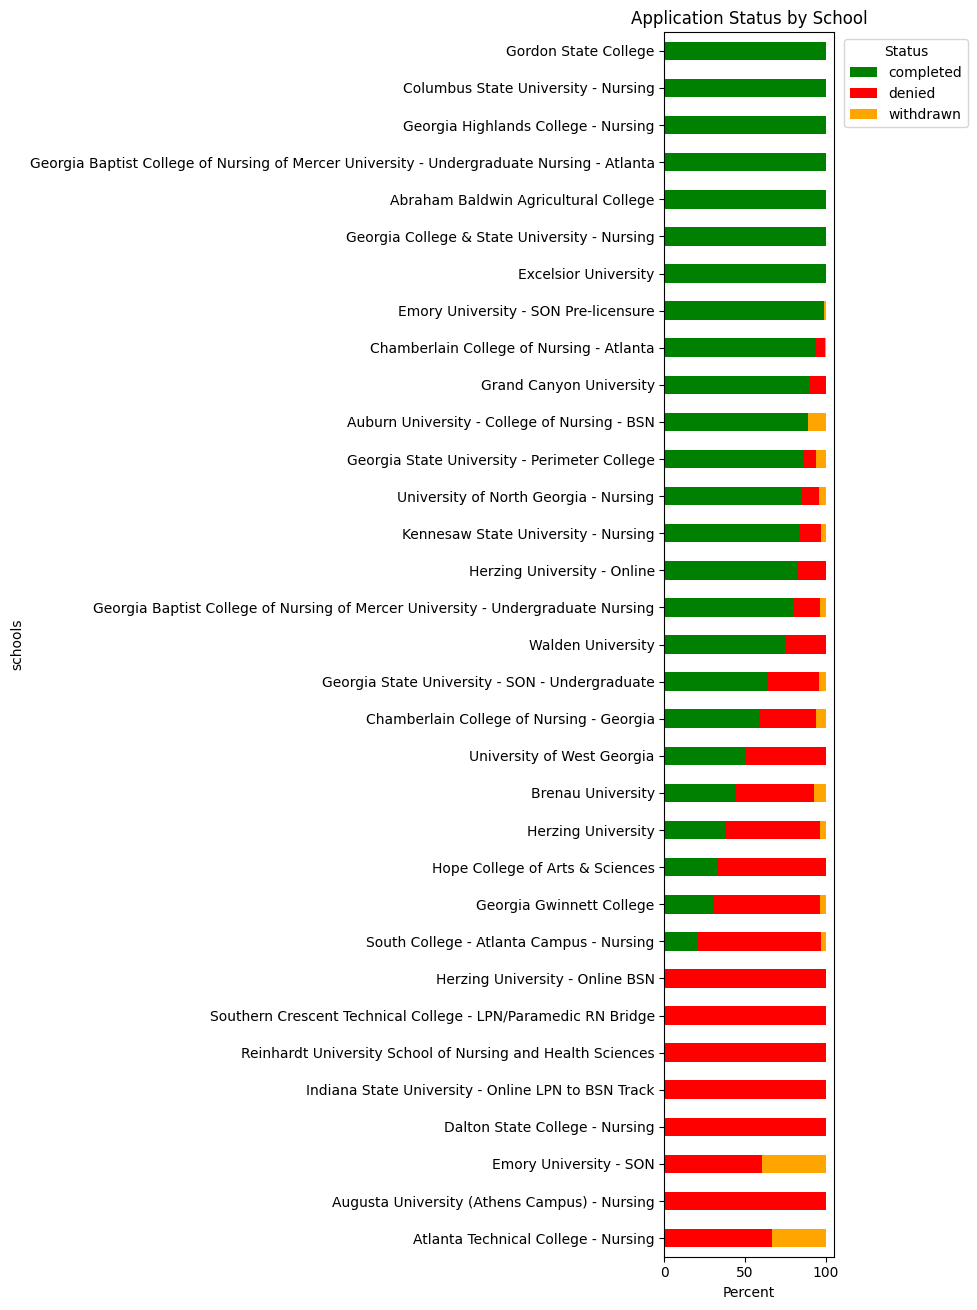

In [40]:
pct_all = percentages.sort_values('completed', ascending=True)

ax = pct_all.plot(
    kind='barh',
    stacked=True,
    figsize=(10, max(6, 0.4 * len(pct_all))),  # auto-adjust height
    color=['green', 'red', 'orange']
)

ax.set_xlabel('Percent')
ax.set_title('Application Status by School')

plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## how many students accepted

In [41]:
accepted_counts = (
    rot_student_level[rot_student_level['status_clean'] == 'completed']
      .groupby('schools')
      .size()
      .sort_values(ascending=True)
)
accepted_counts

,0
schools,
Abraham Baldwin Agricultural College,1
Excelsior University,1
Georgia Highlands College - Nursing,1
Gordon State College,1
University of West Georgia,2
Hope College of Arts & Sciences,3
Walden University,3
Columbus State University - Nursing,4
Georgia College & State University - Nursing,6


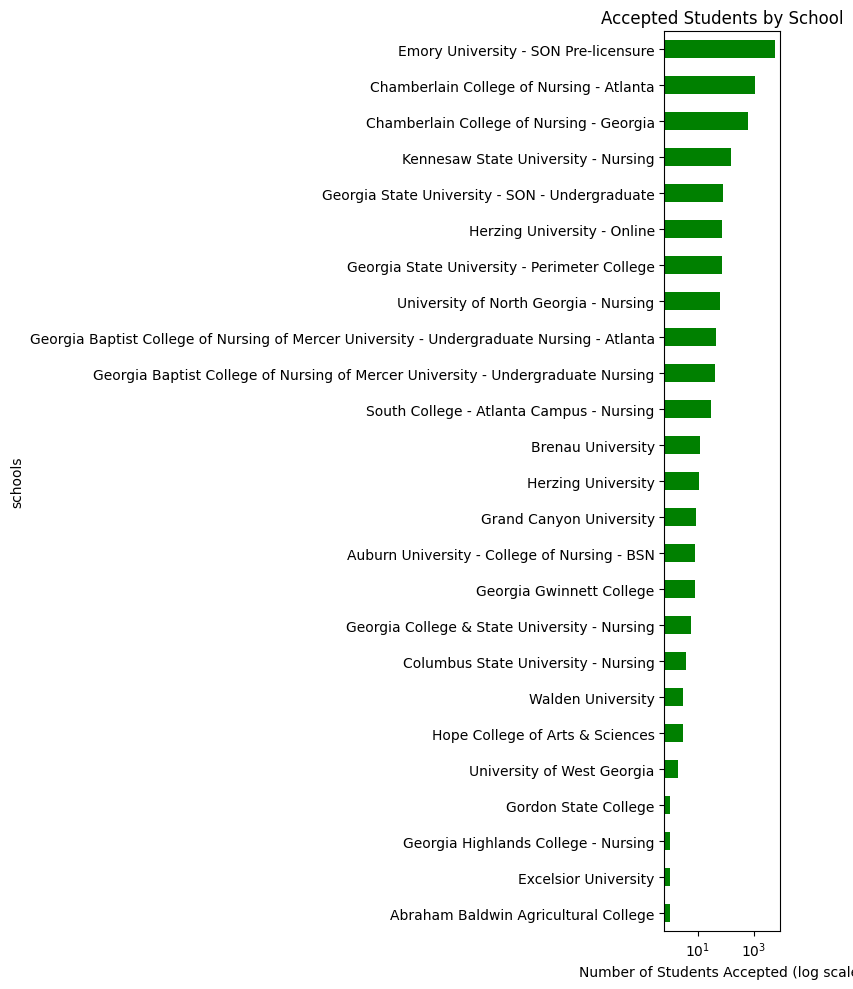

In [42]:
ax = accepted_counts.plot(
    x='schools',
    y='accepted_count',
    kind='barh',
    figsize=(8, max(6, 0.4 * len(accepted_counts))),
    color='green'
)

ax.set_xscale('log')   # log scale because emory has too many in comparison to everyone else
ax.set_xlabel('Number of Students Accepted (log scale)')
ax.set_title('Accepted Students by School')

plt.tight_layout()
plt.show()

## Total number of hours per school

In [43]:
hours_by_school = (
    rot_student_level
      .groupby('schools')['total_hours_per_person']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

hours_by_school

,schools,total_hours_per_person
0,Emory University - SON Pre-licensure,366836
1,Chamberlain College of Nursing - Atlanta,87169
2,Chamberlain College of Nursing - Georgia,79924
3,South College - Atlanta Campus - Nursing,12780
4,Kennesaw State University - Nursing,12326
5,Herzing University - Online,8814
6,Georgia State University - SON - Undergraduate,8280
7,Emory University - SON,6386
8,Georgia State University - Perimeter College,5776
9,University of North Georgia - Nursing,5760


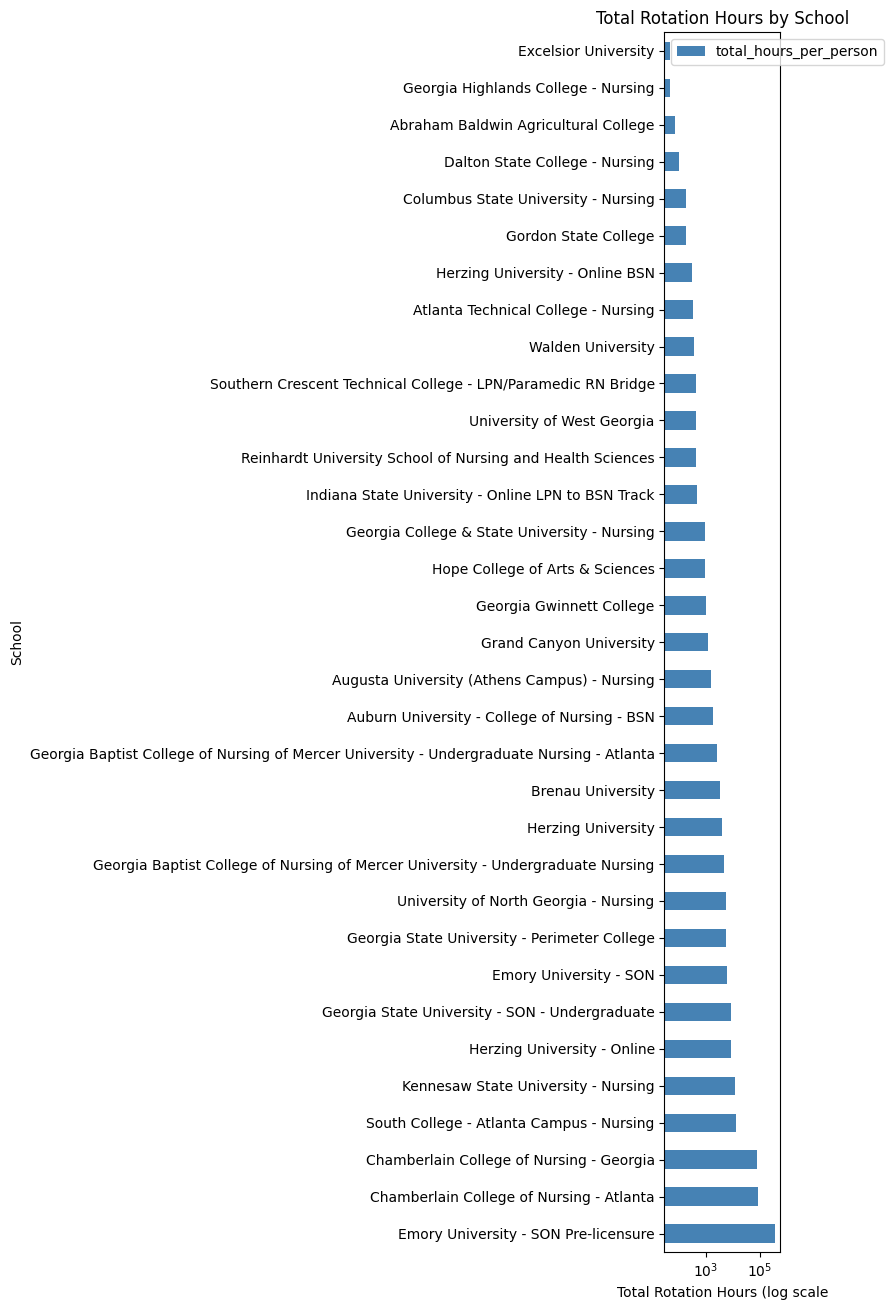

In [44]:
ax = hours_by_school.plot(
    x='schools',
    y='total_hours_per_person',
    kind='barh',
    figsize=(8, max(6, 0.4 * len(hours_by_school))),
    color='steelblue'
)

ax.set_xscale('log')
ax.set_xlabel('Total Rotation Hours (log scale')
ax.set_ylabel('School')
ax.set_title('Total Rotation Hours by School')

plt.tight_layout()
plt.show()

## Distribution of Clinical Hours by Rotation Type

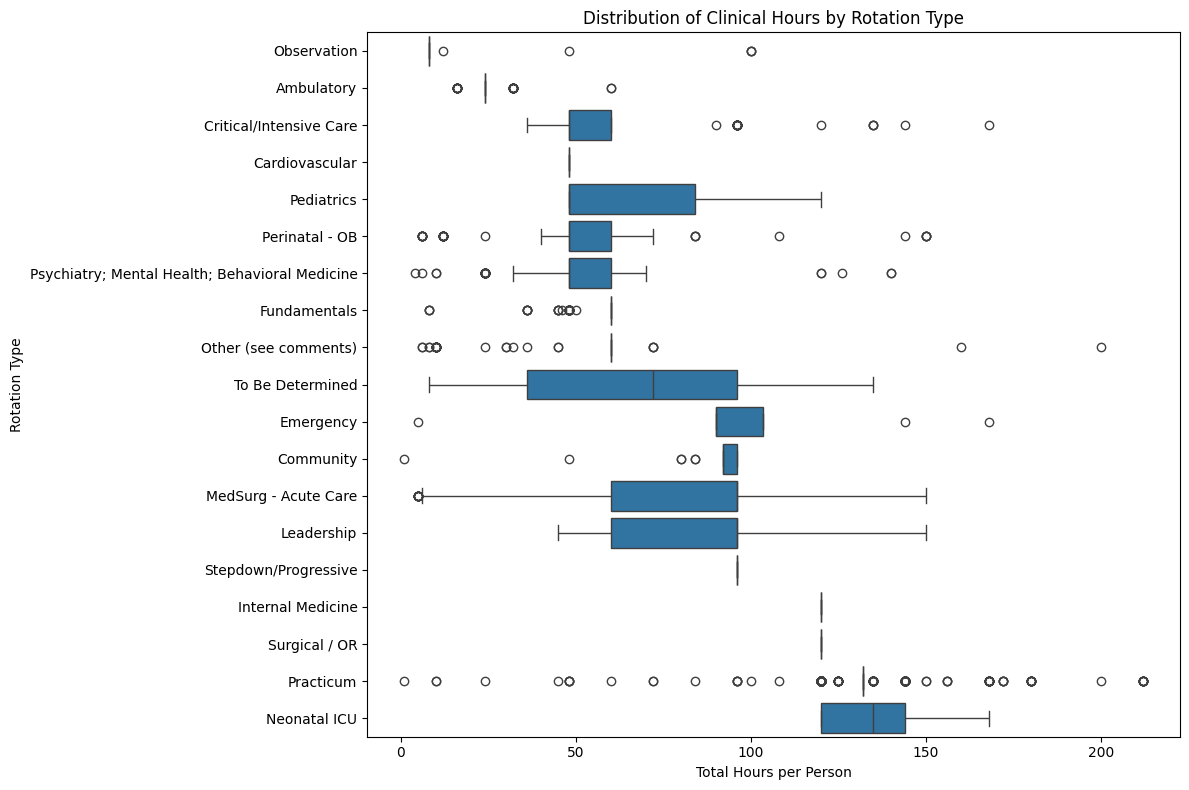

In [47]:
order = (
    rot_sched
    .groupby('rotation_type')['total_hours_per_person']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=rot_sched,
    x='total_hours_per_person',
    y='rotation_type',
    order=order
)

plt.xlabel('Total Hours per Person')
plt.ylabel('Rotation Type')
plt.title('Distribution of Clinical Hours by Rotation Type')

plt.tight_layout()
plt.show()